# Source-to-derived pairing and anatomy forensics

## tl;dr

- **156/156** representative and screenshot samples regenerate exactly from their named NIfTI source slice.
- Every local offset search selects **offset 0**. File naming, slice numbering, and deterministic PNG conversion are correct in the audited samples.
- Independent legacy LiTS references confirm an image/mask transform disagreement for **volumes 83–99**.
- Body-outline, organ-intensity, boundary-gradient, centroid, and tumor-placement evidence identifies the same failure signature in **volumes 101–130**.
- The affected set is **83–99 and 101–130 (47 volumes)**. Their current organ and tumor masks require a 180-degree correction in a new build.
- Adjacent-slice continuity remains smooth in the failed volumes, so continuity alone cannot detect an in-plane rotation.
- Tiny beginning/end components in examples such as volumes 4, 33, and 44 regenerate exactly from the source and change smoothly across adjacent slices. They are source boundary annotations, not filename or resize corruption.

**Decision: the current staged build is not eligible for promotion or training.**

## Context & Methods

The audit separates four possible failure layers:

1. filename/key pairing;
2. slice offset or reversed order;
3. deterministic source-to-derived conversion;
4. anatomical alignment between the CT source and segmentation source.

Exact regeneration proves layers 1–3, but it cannot validate layer 4 when the CT and segmentation NIfTI arrays themselves use incompatible orientations. Anatomy-derived tests therefore compare identity versus 180-degree mask placement using non-air body overlap, image intensity under the organ/tumor masks, image-gradient agreement at mask boundaries, centroid plausibility, and trusted legacy LiTS references where available.

### Key assumptions

- Images use the recorded fixed CT window: center 40 HU, width 400 HU.
- Masks are binary 256x256 PNGs derived with nearest-neighbour resizing.
- Legacy LiTS PNG image/liver/lesion masks for volumes 78–99 are an independent pairing reference.
- Diagnostic transform search identifies the failure; corrections must be applied deterministically in a new build and recorded in provenance.

In [1]:
# Setup and optional forensic rerun
from pathlib import Path
import json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
RESULTS_DIR = PROJECT_ROOT / "Practice" / "dataset_pairing_forensics_results"
FORENSIC_SCRIPT = PROJECT_ROOT / "Practice" / "run_dataset_pairing_forensics.py"
RUN_FORENSICS = False  # Set True to recompute all reports from the staged dataset.

if RUN_FORENSICS:
    subprocess.run([sys.executable, str(FORENSIC_SCRIPT)], check=True)

assert RESULTS_DIR.is_dir(), f"Missing results directory: {RESULTS_DIR}"
print("Results:", RESULTS_DIR)


Results: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\dataset_pairing_forensics_results


## Data

In [2]:
# Load forensic evidence
summary = json.loads((RESULTS_DIR / "forensic_summary.json").read_text(encoding="utf-8"))
pairing = pd.read_csv(RESULTS_DIR / "slice_pairing_audit.csv")
offsets = pd.read_csv(RESULTS_DIR / "offset_candidates.csv")
legacy = pd.read_csv(RESULTS_DIR / "legacy_reference_transform_audit.csv")
orientation = pd.read_csv(RESULTS_DIR / "orientation_candidates.csv")
volume_summary = pd.read_csv(RESULTS_DIR / "volume_pairing_summary.csv")
components = pd.read_csv(RESULTS_DIR / "native_component_audit.csv")
failures = pd.read_csv(RESULTS_DIR / "pairing_failures.csv")

pd.DataFrame({
    "metric": [
        "Manifest rows",
        "Pairing samples",
        "Exact source regenerations",
        "Zero-offset matches",
        "Legacy-reference volumes",
        "Critical orientation failures",
    ],
    "value": [
        summary["manifest_rows"],
        summary["representative_and_screenshot_pairing_rows"],
        summary["source_regeneration_pass_rows"],
        summary["zero_offset_rows"],
        summary["legacy_reference_volumes"],
        summary["critical_failure_count"],
    ],
})


,metric,value
0,Manifest rows,58638
1,Pairing samples,156
2,Exact source regenerations,156
3,Zero-offset matches,156
4,Legacy-reference volumes,25
5,Critical orientation failures,47


## Results

In [3]:
# 1. Source regeneration and slice-offset results
pairing_summary = pd.DataFrame({
    "check": ["Image exact", "Organ exact", "Tumor exact", "Best offset equals zero"],
    "passed": [
        int(pairing.image_pixel_exact.sum()),
        int(pairing.organ_exact.sum()),
        int(pairing.tumor_exact.sum()),
        int(pairing.best_offset.eq(0).sum()),
    ],
    "tested": [len(pairing)] * 4,
})
display(pairing_summary)

print("Interpretation: saved files come from the named source volume and slice in every audited representative/screenshot sample.")
print("This does not prove the CT and segmentation source arrays are anatomically aligned.")


,check,passed,tested
0,Image exact,156,156
1,Organ exact,156,156
2,Tumor exact,156,156
3,Best offset equals zero,156,156


Interpretation: saved files come from the named source volume and slice in every audited representative/screenshot sample.
This does not prove the CT and segmentation source arrays are anatomically aligned.


In [4]:
# 2. Independent legacy-reference transform agreement
legacy_display = legacy[[
    "volume_id", "slice_index", "image_best_transform", "image_correlation",
    "mask_best_transform", "mask_dice", "image_mask_transform_agree",
]].copy()
display(legacy_display)

confirmed_failures = legacy.loc[~legacy.image_mask_transform_agree, "volume_id"].astype(int).tolist()
print("Confirmed transform disagreements:", confirmed_failures)
print("Volumes 78-82 use the same transpose for image and mask; volumes 83-99 use transpose for image and anti-transpose for mask.")


,volume_id,slice_index,image_best_transform,image_correlation,mask_best_transform,mask_dice,image_mask_transform_agree
0,7,373,rot90,0.842926,rot90,0.987121,True
1,8,379,rot90,0.871145,rot90,0.989394,True
2,9,386,rot90,0.871761,rot90,0.986399,True
3,78,166,transpose,0.701130,transpose,0.993563,True
4,79,116,transpose,0.843387,transpose,0.992510,True
5,80,162,transpose,0.880403,transpose,0.992760,True
6,81,246,transpose,0.641002,transpose,0.989714,True
7,82,400,transpose,0.831241,transpose,0.992866,True
8,83,570,transpose,0.914180,anti_transpose,0.988782,False
9,84,554,transpose,0.881836,anti_transpose,0.993925,False


Confirmed transform disagreements: [83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Volumes 78-82 use the same transpose for image and mask; volumes 83-99 use transpose for image and anti-transpose for mask.


In [5]:
# 3. Multi-metric orientation evidence by cohort
orientation["boundary_delta_rot_minus_identity"] = (
    orientation.rot180_boundary_gradient - orientation.identity_boundary_gradient
)
orientation["tumor_intensity_delta_rot_minus_identity"] = (
    orientation.rot180_tumor_mean_intensity - orientation.identity_tumor_mean_intensity
)
orientation["tumor_nonair_delta_rot_minus_identity"] = (
    orientation.rot180_tumor_nonair_fraction - orientation.identity_tumor_nonair_fraction
)

group_metrics = orientation.groupby("recommended_transform").agg(
    volumes=("volume_id", "count"),
    organ_intensity_delta=("organ_intensity_delta_rot_minus_identity", "mean"),
    organ_nonair_delta=("organ_nonair_delta_rot_minus_identity", "mean"),
    boundary_gradient_delta=("boundary_delta_rot_minus_identity", "mean"),
    tumor_intensity_delta=("tumor_intensity_delta_rot_minus_identity", "mean"),
    tumor_nonair_delta=("tumor_nonair_delta_rot_minus_identity", "mean"),
    median_adjacent_dice=("median_adjacent_organ_dice", "median"),
).reset_index()
display(group_metrics.round(3))

print("Recommended rot180 volumes:", summary["recommended_rot180_volumes"])


,recommended_transform,volumes,organ_intensity_delta,organ_nonair_delta,boundary_gradient_delta,tumor_intensity_delta,tumor_nonair_delta,median_adjacent_dice
0,identity,84,-60.302,-0.155,-58.331,-36.011,-0.134,0.974
1,rot180,47,63.385,0.148,57.543,31.153,0.099,0.985


Recommended rot180 volumes: [83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]


orientation_score_by_volume.png


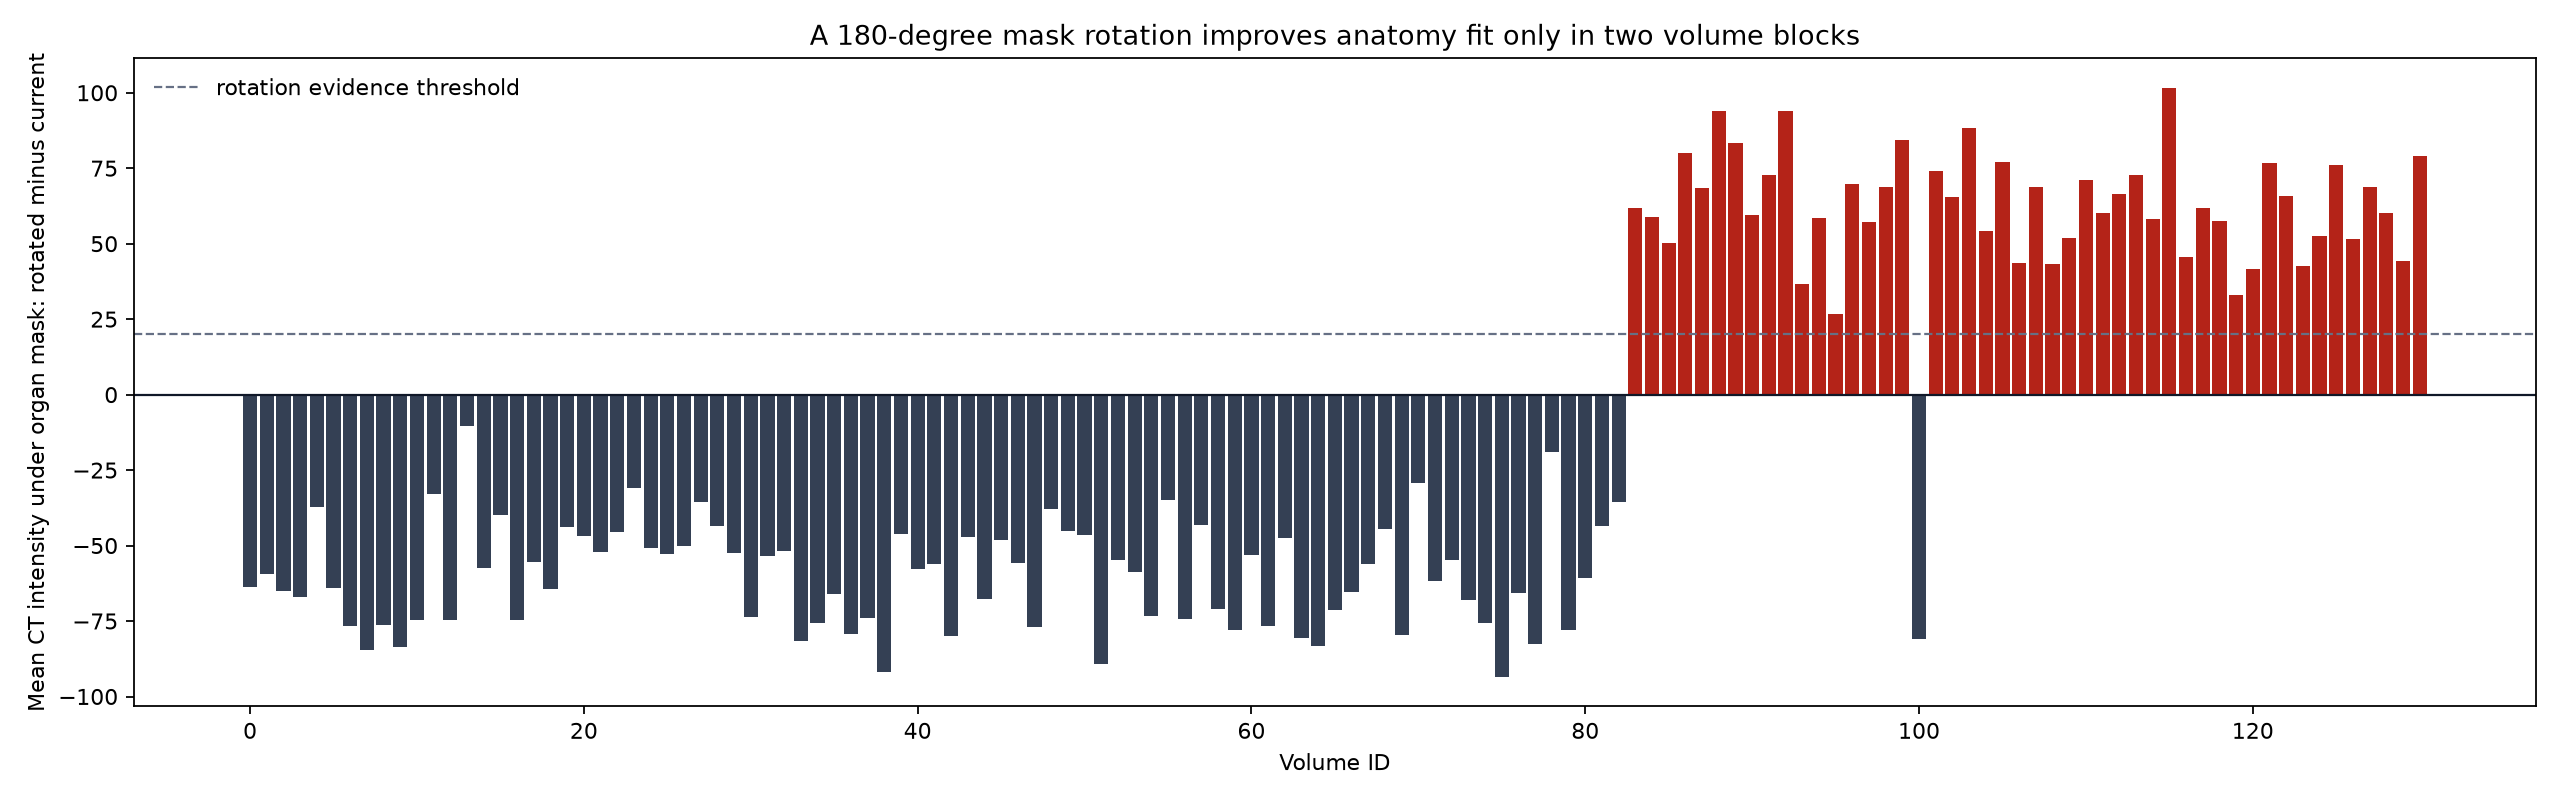

orientation_evidence_scatter.png


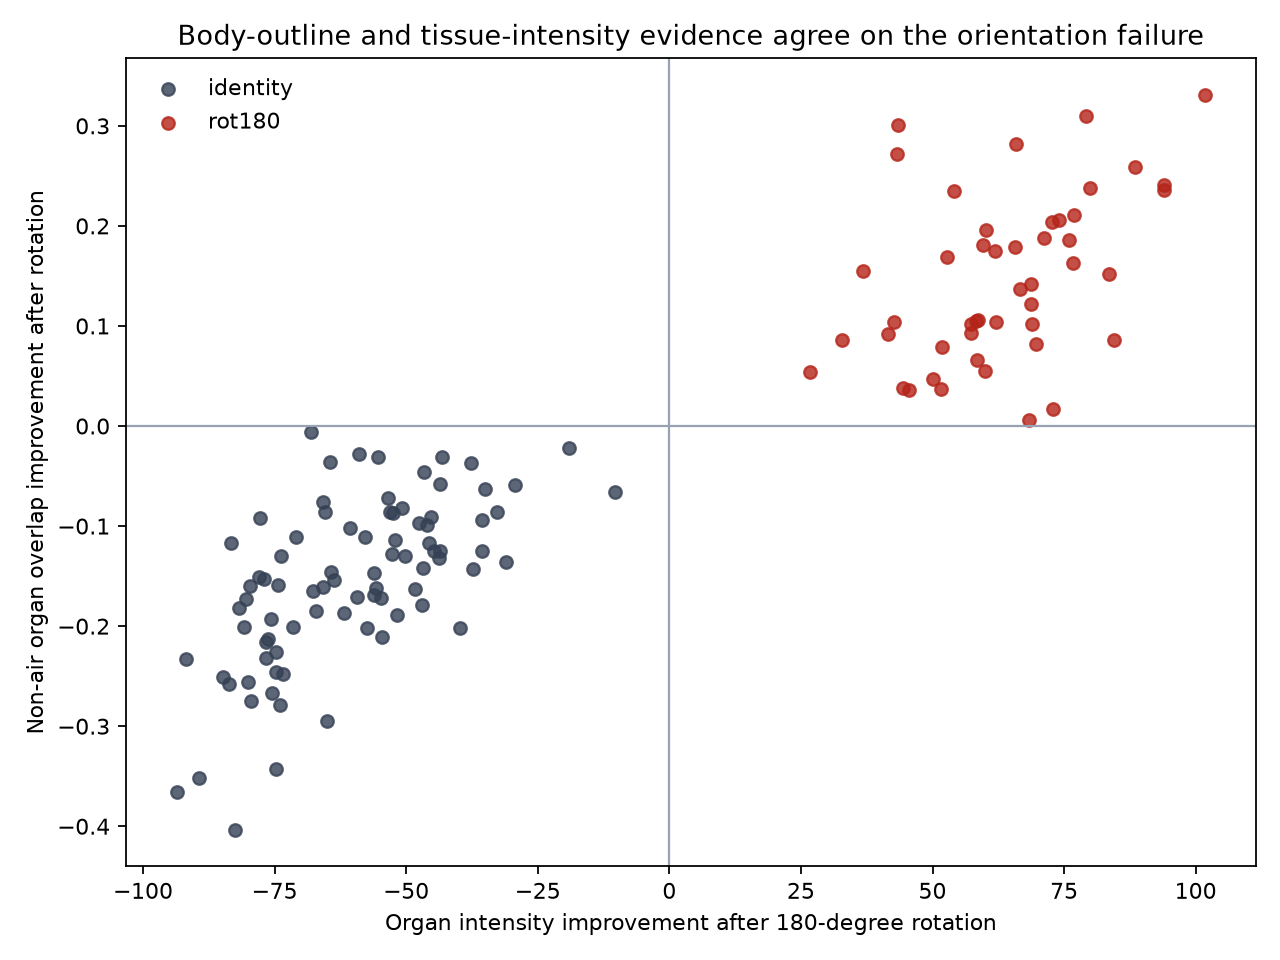

continuity_by_volume.png


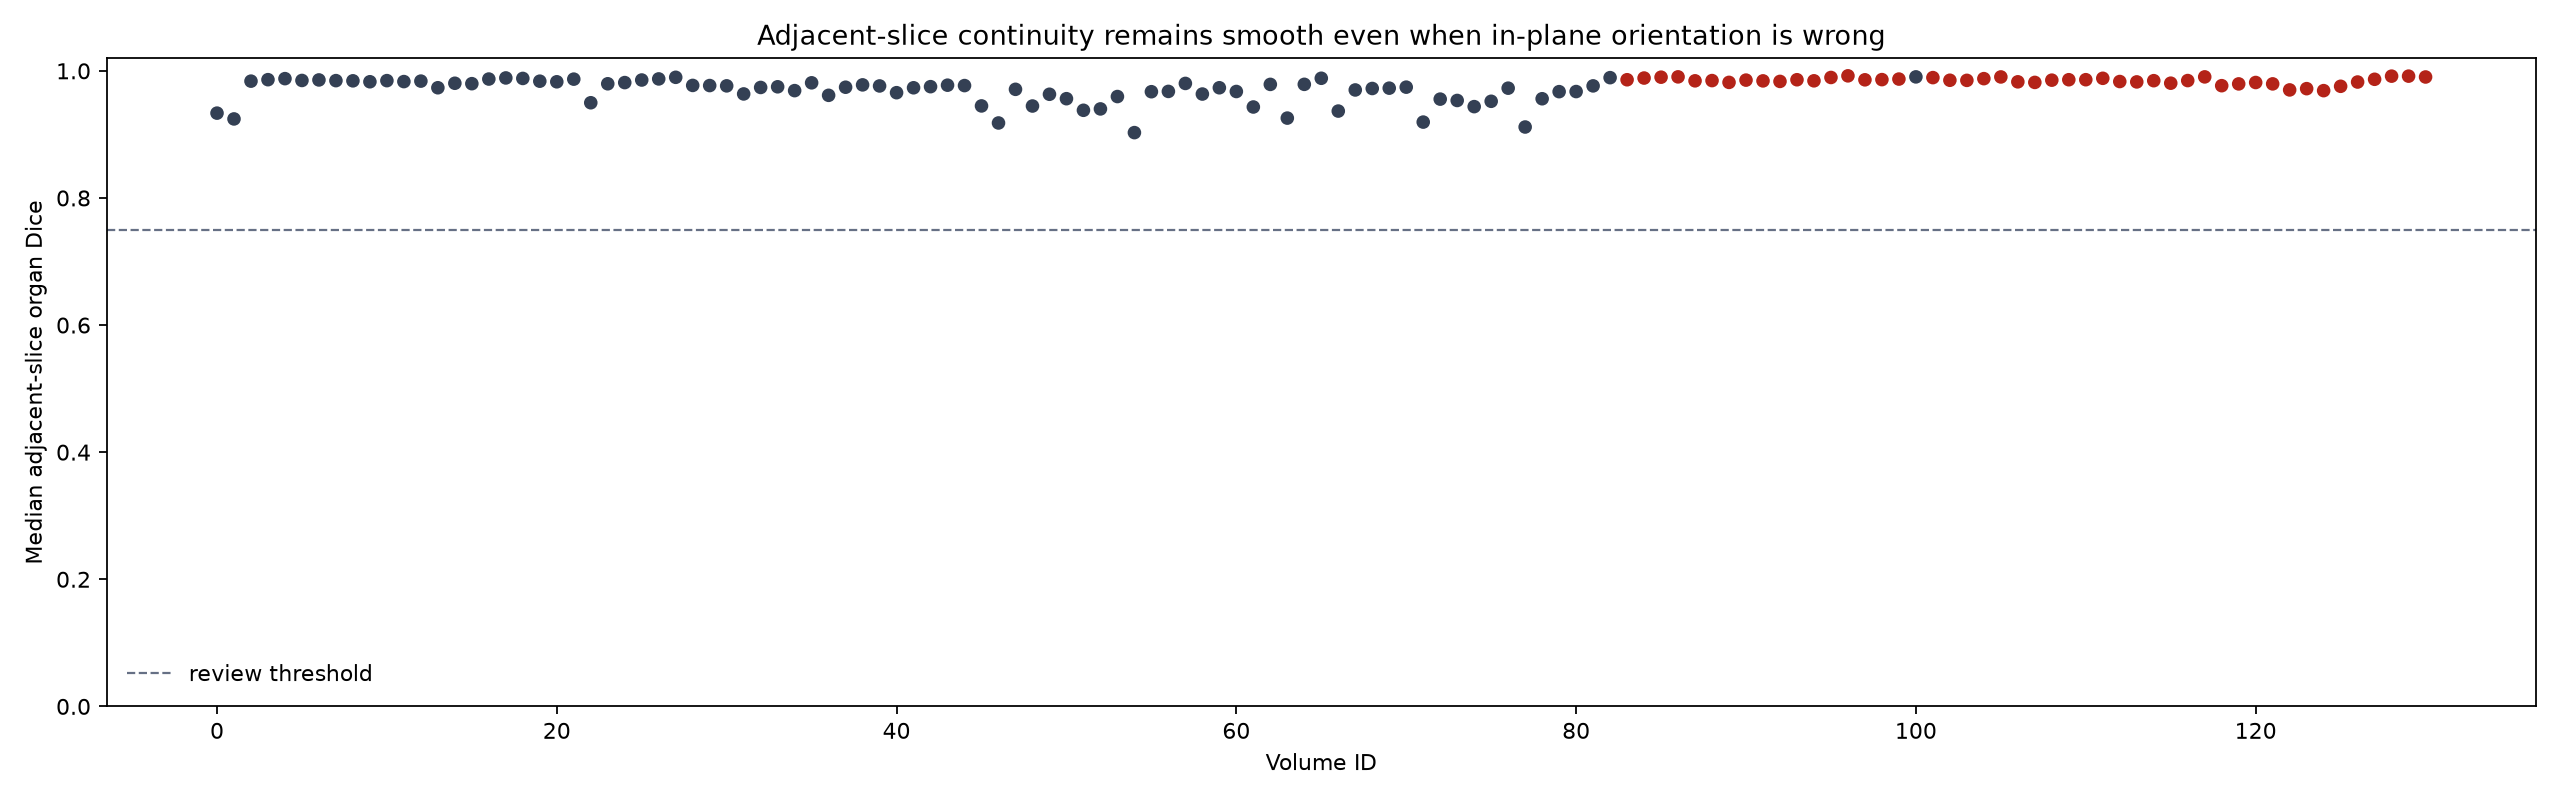

In [6]:
# 4. Orientation evidence figures
for filename in [
    "orientation_score_by_volume.png",
    "orientation_evidence_scatter.png",
    "continuity_by_volume.png",
]:
    print(filename)
    display(Image(filename=str(RESULTS_DIR / filename), width=1150))


,volume_id,recommended_transform,tumor_positive_slices,tumor_component_count_2d,tiny_tumor_component_count_lt10px,tiny_organ_slices_lt100px,median_adjacent_organ_dice
117,117,rot180,245,1696,410,8,0.990496
16,16,identity,120,540,198,7,0.987094
96,96,rot180,210,449,190,3,0.992143
98,98,rot180,140,610,157,6,0.986210
27,27,identity,144,411,131,5,0.989828
108,108,rot180,202,2230,126,2,0.985337
130,130,rot180,199,543,125,3,0.990336
84,84,rot180,219,638,114,5,0.988676
4,4,identity,244,629,96,5,0.987735
19,19,identity,48,137,59,5,0.983720


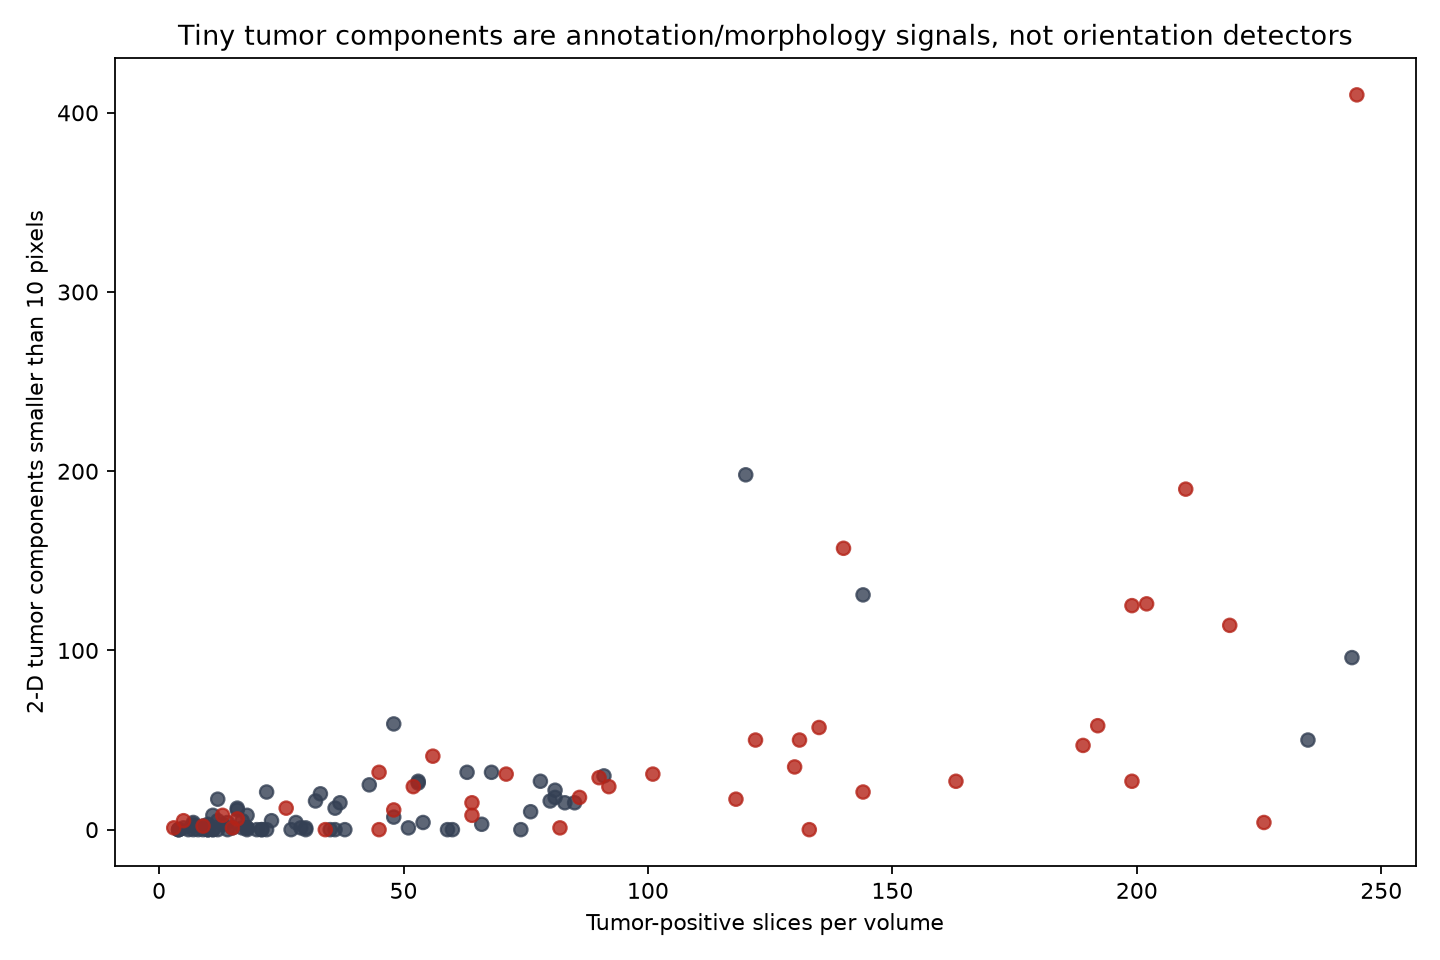

Tiny components require annotation review, but they do not diagnose orientation because rotation preserves size, shape, and connected-component counts.


In [7]:
# 5. Tiny components and tumor morphology
top_tiny = volume_summary.nlargest(15, "tiny_tumor_component_count_lt10px")[[
    "volume_id", "recommended_transform", "tumor_positive_slices",
    "tumor_component_count_2d", "tiny_tumor_component_count_lt10px",
    "tiny_organ_slices_lt100px", "median_adjacent_organ_dice",
]]
display(top_tiny)
display(Image(filename=str(RESULTS_DIR / "tumor_component_profile.png"), width=900))

print("Tiny components require annotation review, but they do not diagnose orientation because rotation preserves size, shape, and connected-component counts.")


In [8]:
# 6. Adjacent-slice area continuity around screenshot edge components
manifest = pd.read_csv(
    Path(r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging\build_20260713_112738")
    / "manifests" / "slice_manifest.csv"
)
examples = [(4, 347), (33, 37), (33, 132), (44, 1), (44, 113), (84, 393), (85, 335)]
continuity_rows = []
for volume_id, center_slice in examples:
    nearby = manifest[
        (manifest.volume_id == volume_id)
        & manifest.slice_index.between(max(0, center_slice - 5), center_slice + 5)
    ][["volume_id", "slice_index", "organ_pixels_256", "tumor_pixels_256"]].copy()
    nearby["review_center"] = center_slice
    continuity_rows.append(nearby)

continuity_examples = pd.concat(continuity_rows, ignore_index=True)
display(continuity_examples)
print("The small components rise or fall smoothly across neighbouring slices and exactly regenerate from source labels.")


,volume_id,slice_index,organ_pixels_256,tumor_pixels_256,review_center
0,4,342,0,0,347
1,4,343,0,0,347
2,4,344,0,0,347
3,4,345,0,0,347
4,4,346,0,0,347
...,...,...,...,...,...
65,85,336,72,0,335
66,85,337,101,0,335
67,85,338,126,0,335
68,85,339,154,0,335


The small components rise or fall smoothly across neighbouring slices and exactly regenerate from source labels.


## Takeaways

1. **Not a filename or off-by-one failure.** Every audited sample is pixel-exact against its named source slice and selects offset 0.
2. **Not a PNG resizing artifact.** Images and masks reproduce the deterministic conversion exactly.
3. **A source-orientation failure.** For volumes 83–99, the independent image reference requires `transpose`, while the trusted mask reference requires `anti_transpose`. These differ by 180 degrees.
4. **The same signature extends to 101–130.** Organ intensity, body overlap, boundary-gradient agreement, centroid plausibility, and tumor placement all improve under a 180-degree correction.
5. **Continuity is necessary but insufficient.** Median adjacent-slice Dice is approximately 0.97–0.99 in both groups because applying the same wrong rotation to every slice preserves 3-D smoothness.
6. **Tiny edge components are mostly source annotations.** The examined examples are present in the source segmentation and progress smoothly across adjacent slices. They still merit annotation QA, but they are not evidence of misnaming.

### Required action

- Reject the current staged build for promotion.
- Rebuild volumes **83–99 and 101–130** with the CT and segmentation placed in one documented orientation. Given the current derived images, the diagnosed mask correction is `np.rot90(mask, 2)` for both organ and tumor masks.
- Use a new build ID; do not mutate the failed build.
- Regenerate manifests, hashes, spatial reviews, and all forensic reports.
- Require exact reference agreement for volumes 78–99 and multi-metric plus manual review for 101–130 before training.